# Broad Learning System


Processing horizon: 96

Results for Horizon: 96
Trend Training Time: 0.03 seconds
Trend Prediction Time: 0.0061 seconds
Seasonal Training Time: 0.01 seconds
Seasonal Prediction Time: 0.0000 seconds
Total Training Time: 0.04 seconds
Total Prediction Time: 0.0061 seconds
Trend MSE: 0.006949
Trend MAE: 0.053867
Trend R²: -3721.261703
Seasonal MSE: 0.005093
Seasonal MAE: 0.044313
Seasonal R²: 0.994595
Combined MSE: 0.189049
Combined MAE: 0.249903
Combined R²: -0.474503


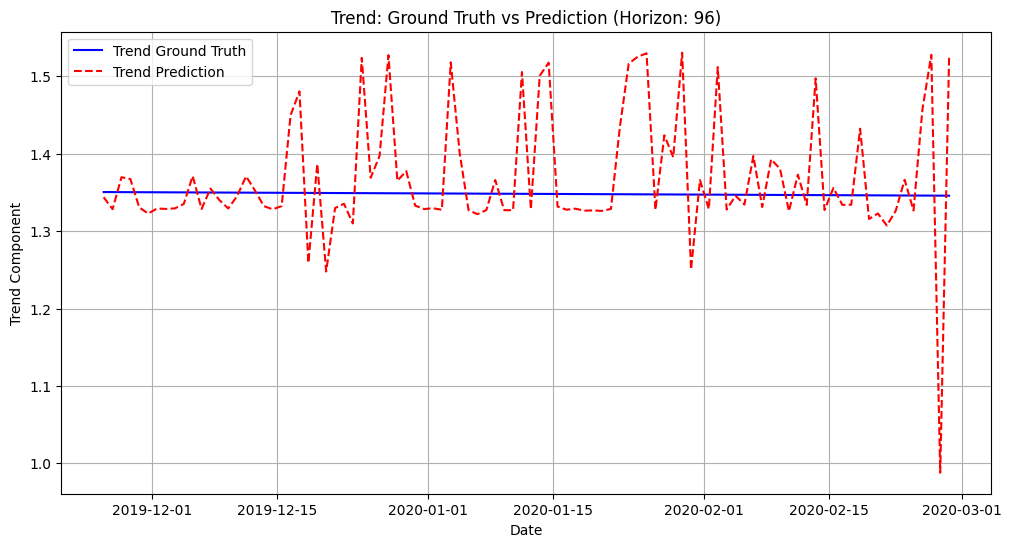

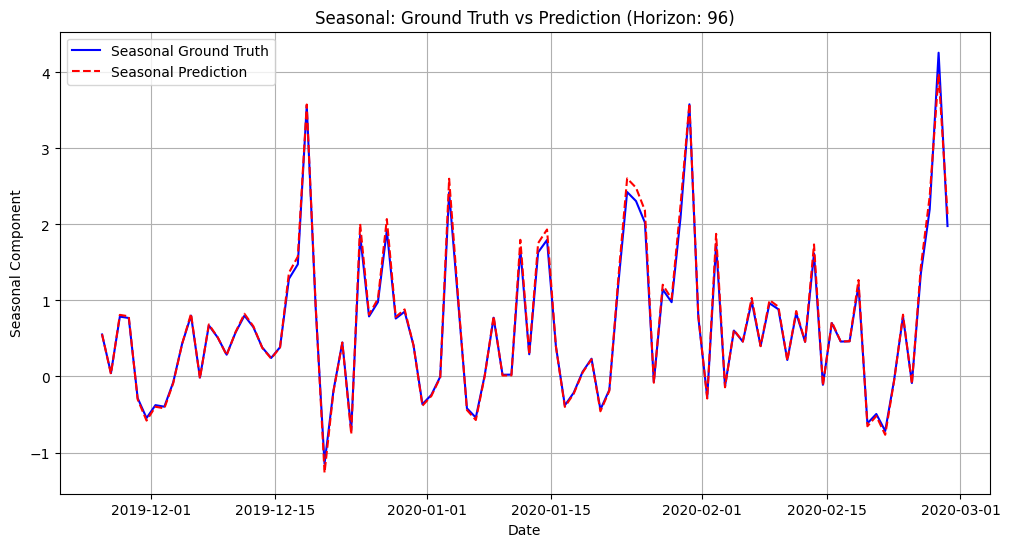

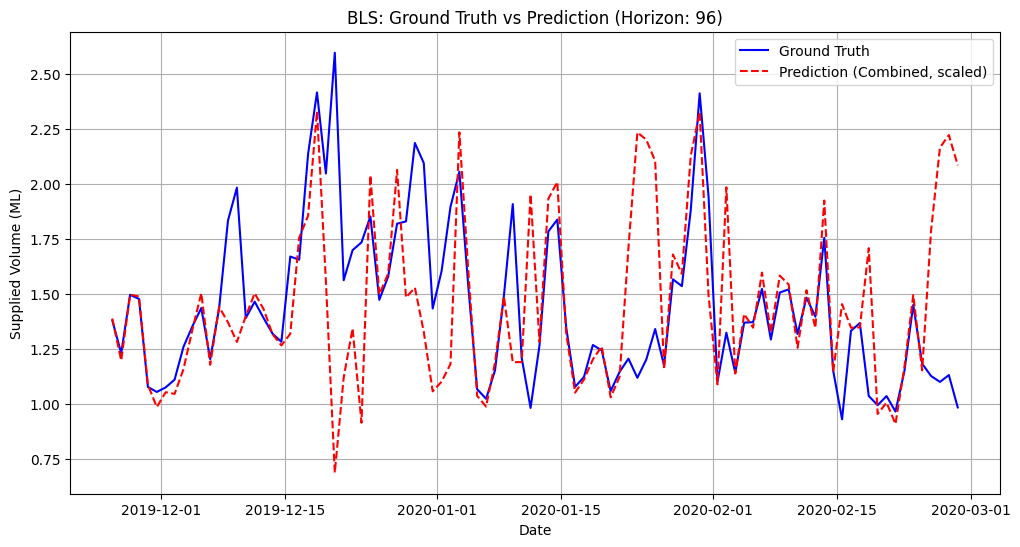


Processing horizon: 192

Results for Horizon: 192
Trend Training Time: 0.01 seconds
Trend Prediction Time: 0.0000 seconds
Seasonal Training Time: 0.02 seconds
Seasonal Prediction Time: 0.0000 seconds
Total Training Time: 0.03 seconds
Total Prediction Time: 0.0000 seconds
Trend MSE: 0.005094
Trend MAE: 0.050400
Trend R²: -755.868593
Seasonal MSE: 0.004494
Seasonal MAE: 0.047799
Seasonal R²: 0.995339
Combined MSE: 0.102808
Combined MAE: 0.165724
Combined R²: 0.178531


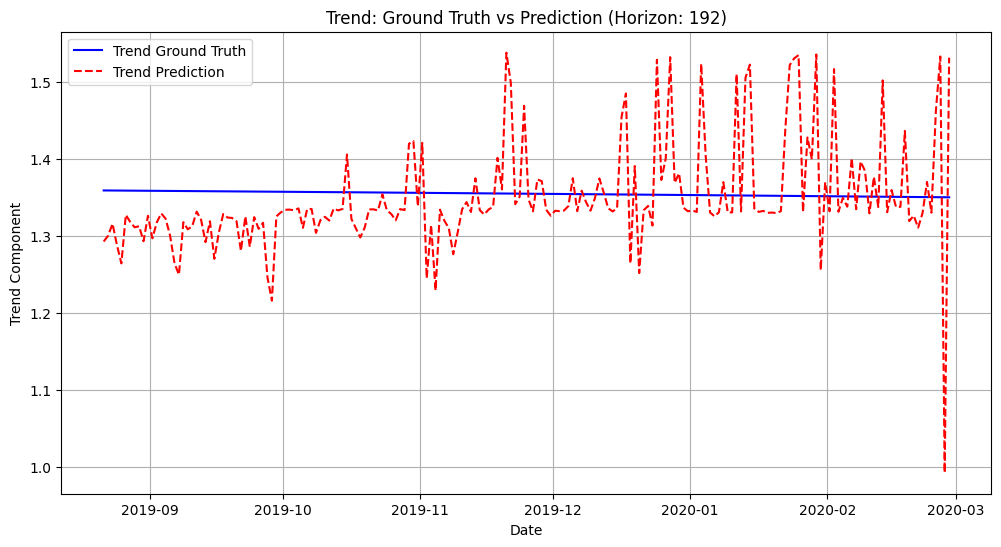

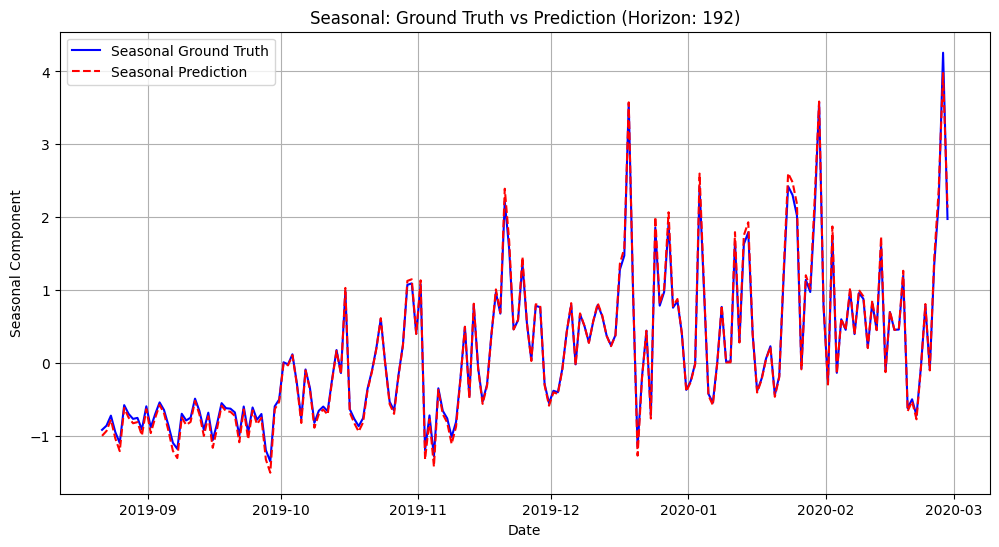

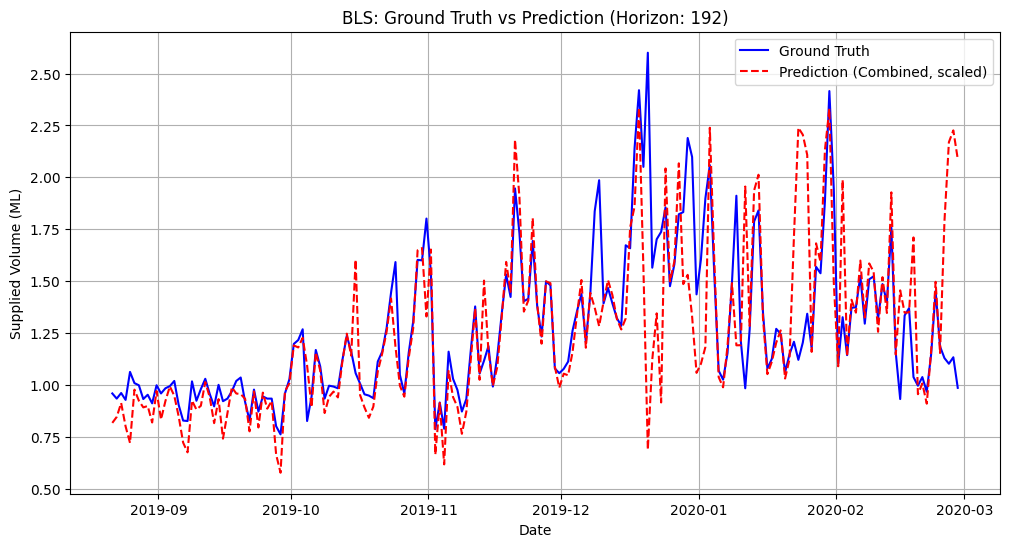


Processing horizon: 336

Results for Horizon: 336
Trend Training Time: 0.01 seconds
Trend Prediction Time: 0.0000 seconds
Seasonal Training Time: 0.01 seconds
Seasonal Prediction Time: 0.0000 seconds
Total Training Time: 0.02 seconds
Total Prediction Time: 0.0000 seconds
Trend MSE: 0.004434
Trend MAE: 0.050473
Trend R²: -274.589283
Seasonal MSE: 0.004464
Seasonal MAE: 0.051361
Seasonal R²: 0.994315
Combined MSE: 0.066430
Combined MAE: 0.131858
Combined R²: 0.322497


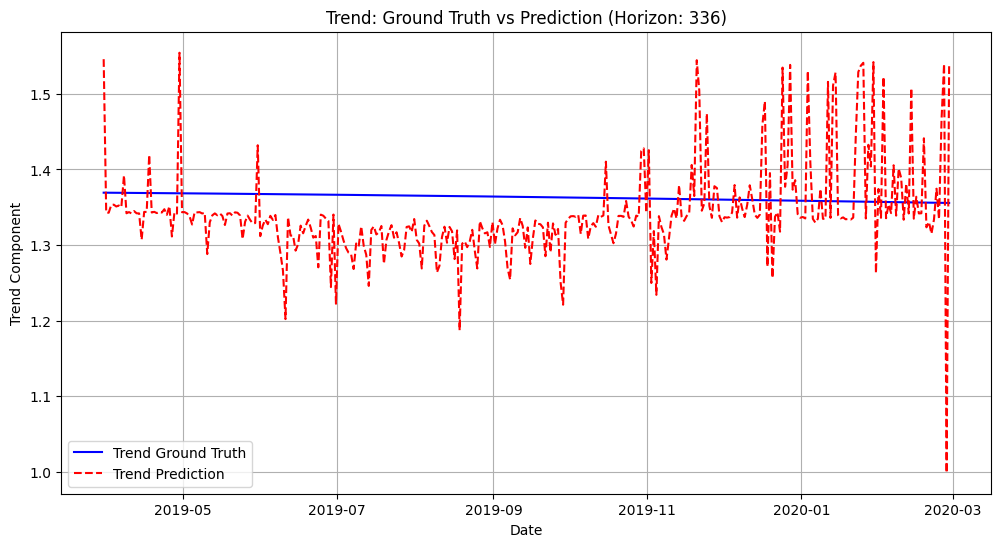

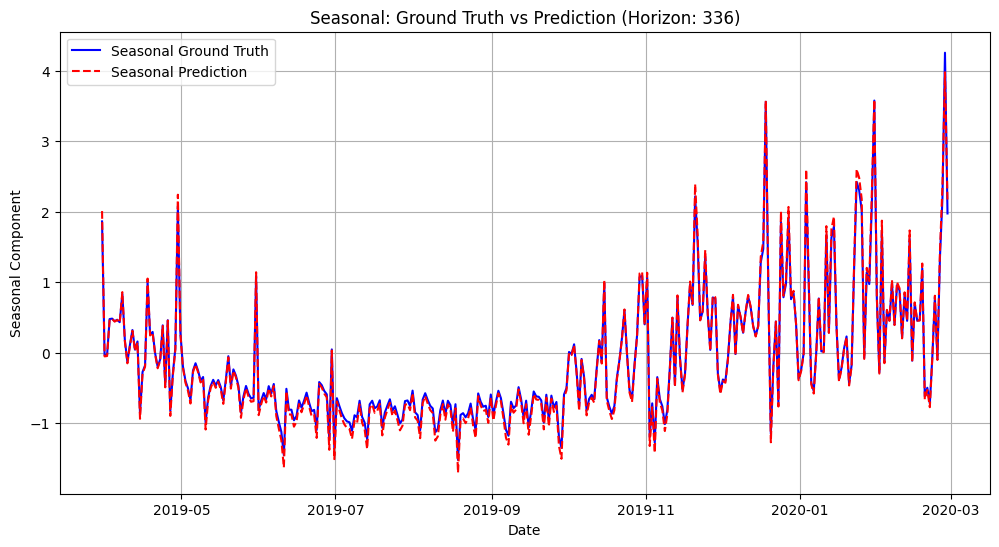

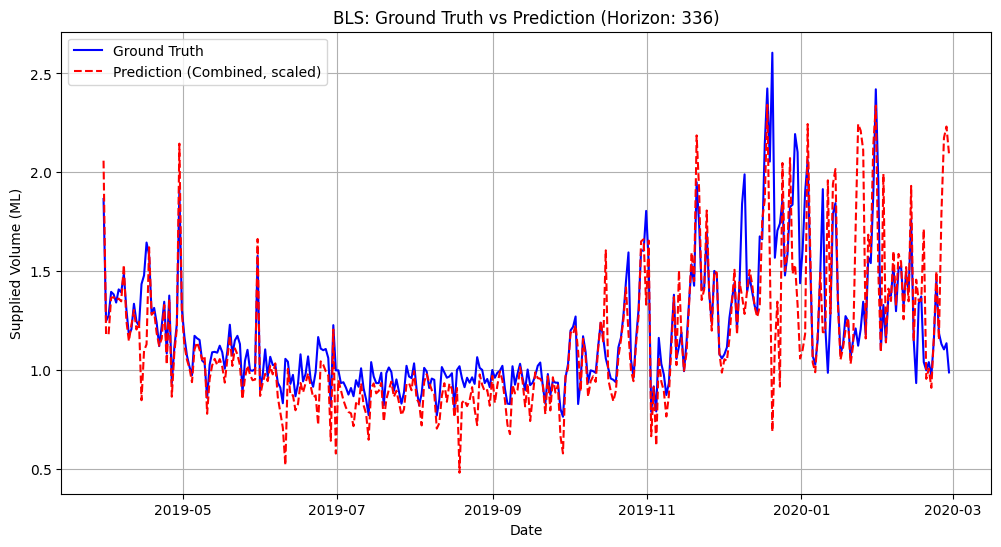


Processing horizon: 720

Results for Horizon: 720
Trend Training Time: 0.01 seconds
Trend Prediction Time: 0.0000 seconds
Seasonal Training Time: 0.01 seconds
Seasonal Prediction Time: 0.0000 seconds
Total Training Time: 0.02 seconds
Total Prediction Time: 0.0000 seconds
Trend MSE: 0.004178
Trend MAE: 0.049353
Trend R²: -34.723629
Seasonal MSE: 0.004112
Seasonal MAE: 0.049935
Seasonal R²: 0.994760
Combined MSE: 0.069296
Combined MAE: 0.153116
Combined R²: 0.457024


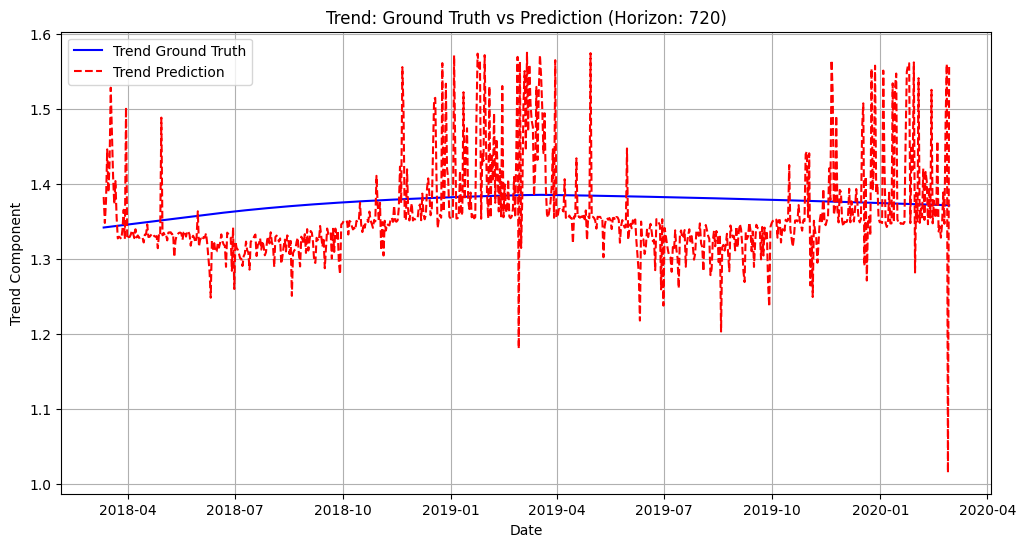

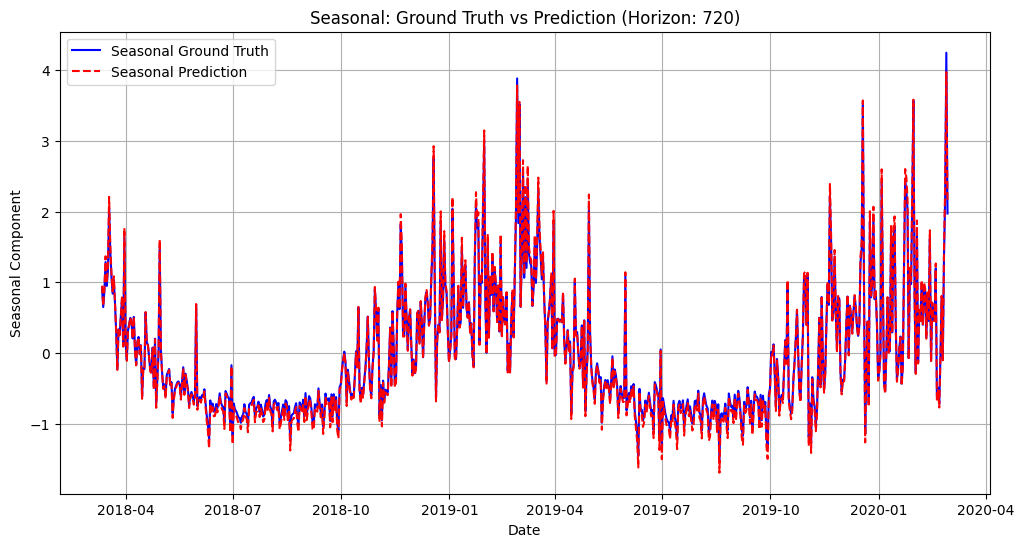

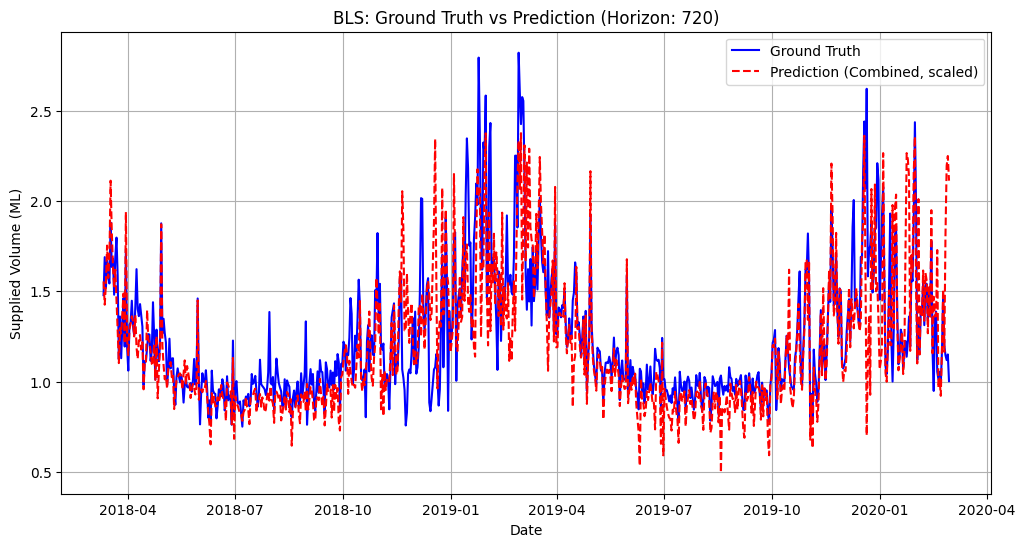

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time
import warnings
from statsmodels.tsa.seasonal import STL
warnings.filterwarnings("ignore", category=FutureWarning, message=".*force_all_finite.*")
np.random.seed(42)
df = pd.read_csv('Water Supply - Daily Volume Drawn from storage dams operated by Melbourne Water/MWC_Daily_BulkWaterSupply_CompleteRecord_1674603204298011933.csv')
df['recorddate'] = pd.to_datetime(df['recorddate'], format='%m/%d/%Y %I:%M:%S %p')
df = df.sort_values('recorddate').reset_index(drop=True)
df = df.set_index('recorddate')
df = df[['supplied_ML']].copy()
def decompose_series(df, target_col, period=365):
    stl = STL(df[target_col], period=period, robust=True)
    result = stl.fit()
    df['trend'] = result.trend
    df['seasonal'] = result.seasonal
    df['resid'] = result.resid
    return df
class BLSModel:
    def __init__(self, n_feature_nodes, n_enhancement_nodes, lambda_reg=1.0, random_state=42):
        self.n_feature_nodes = n_feature_nodes
        self.n_enhancement_nodes = n_enhancement_nodes
        self.lambda_reg = lambda_reg
        self.random_state = random_state
        self.weights_feature = None
        self.weights_enhancement = None
        self.beta = None
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        X_normalized = self.scaler_X.fit_transform(X)
        y_normalized = self.scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
        self.weights_feature = np.random.randn(n_features, self.n_feature_nodes)
        feature_nodes = self._sigmoid(np.dot(X_normalized, self.weights_feature))
        self.weights_enhancement = np.random.randn(self.n_feature_nodes, self.n_enhancement_nodes)
        enhancement_nodes = self._sigmoid(np.dot(feature_nodes, self.weights_enhancement))
        Z = np.hstack([feature_nodes, enhancement_nodes])
        ZTZ = Z.T @ Z + self.lambda_reg * np.eye(Z.shape[1])
        self.beta = np.linalg.solve(ZTZ, Z.T @ y_normalized)
        return self
    def predict(self, X):
        X_normalized = self.scaler_X.transform(X)
        feature_nodes = self._sigmoid(np.dot(X_normalized, self.weights_feature))
        enhancement_nodes = self._sigmoid(np.dot(feature_nodes, self.weights_enhancement))
        Z = np.hstack([feature_nodes, enhancement_nodes])
        y_pred_normalized = np.dot(Z, self.beta)
        return self.scaler_y.inverse_transform(y_pred_normalized.reshape(-1, 1)).flatten()
def prepare_data(df, trend_col, seasonal_col, horizon):
    X = df[[trend_col, seasonal_col]].values
    y_trend = df[trend_col].values
    y_seasonal = df[seasonal_col].values
    y_original = df['supplied_ML'].values
    train_size = len(X) - horizon
    X_train = X[:train_size]
    y_trend_train = y_trend[:train_size]
    y_seasonal_train = y_seasonal[:train_size]
    y_original_train = y_original[:train_size]
    X_test = X[train_size:]
    y_trend_test = y_trend[train_size:]
    y_seasonal_test = y_seasonal[train_size:]
    y_original_test = y_original[train_size:]
    return (X_train, y_trend_train, y_seasonal_train, y_original_train,
            X_test, y_trend_test, y_seasonal_test, y_original_test)
def train_and_evaluate(df, target_col, trend_col, seasonal_col, horizon):
    (X_train, y_trend_train, y_seasonal_train, y_original_train,
     X_test, y_trend_test, y_seasonal_test, y_original_test) = prepare_data(df, trend_col, seasonal_col, horizon)
    trend_model = BLSModel(n_feature_nodes=8, n_enhancement_nodes=2, lambda_reg=1.0, random_state=42)
    seasonal_model = BLSModel(n_feature_nodes=8, n_enhancement_nodes=2, lambda_reg=1.0, random_state=42)
    start_time = time.time()
    trend_model.fit(X_train, y_trend_train)
    trend_training_time = time.time() - start_time
    start_time = time.time()
    y_trend_pred = trend_model.predict(X_test)
    trend_prediction_time = time.time() - start_time
    start_time = time.time()
    seasonal_model.fit(X_train, y_seasonal_train)
    seasonal_training_time = time.time() - start_time
    start_time = time.time()
    y_seasonal_pred = seasonal_model.predict(X_test)
    seasonal_prediction_time = time.time() - start_time
    y_combined_pred = y_trend_pred + y_seasonal_pred
    scaler_trend = StandardScaler().fit(y_trend_train.reshape(-1, 1))
    scaler_seasonal = StandardScaler().fit(y_seasonal_train.reshape(-1, 1))
    scaler_combined = StandardScaler().fit(y_original_train.reshape(-1, 1))
    y_trend_test_scaled = scaler_trend.transform(y_trend_test.reshape(-1, 1)).flatten()
    y_trend_pred_scaled = scaler_trend.transform(y_trend_pred.reshape(-1, 1)).flatten()
    y_seasonal_test_scaled = scaler_seasonal.transform(y_seasonal_test.reshape(-1, 1)).flatten()
    y_seasonal_pred_scaled = scaler_seasonal.transform(y_seasonal_pred.reshape(-1, 1)).flatten()
    y_combined_test_scaled = scaler_combined.transform(y_original_test.reshape(-1, 1)).flatten()
    y_combined_pred_scaled = scaler_combined.transform(y_combined_pred.reshape(-1, 1)).flatten()
    trend_mse = mean_squared_error(y_trend_test_scaled, y_trend_pred_scaled)
    trend_mae = mean_absolute_error(y_trend_test_scaled, y_trend_pred_scaled)
    trend_r2 = r2_score(y_trend_test_scaled, y_trend_pred_scaled)
    seasonal_mse = mean_squared_error(y_seasonal_test_scaled, y_seasonal_pred_scaled)
    seasonal_mae = mean_absolute_error(y_seasonal_test_scaled, y_seasonal_pred_scaled)
    seasonal_r2 = r2_score(y_seasonal_test_scaled, y_seasonal_pred_scaled)
    combined_mse = mean_squared_error(y_combined_test_scaled, y_combined_pred_scaled)
    combined_mae = mean_absolute_error(y_combined_test_scaled, y_combined_pred_scaled)
    combined_r2 = r2_score(y_combined_test_scaled, y_combined_pred_scaled)
    print(f"\nResults for Horizon: {horizon}")
    print(f"Trend Training Time: {trend_training_time:.2f} seconds")
    print(f"Trend Prediction Time: {trend_prediction_time:.4f} seconds")
    print(f"Seasonal Training Time: {seasonal_training_time:.2f} seconds")
    print(f"Seasonal Prediction Time: {seasonal_prediction_time:.4f} seconds")
    print(f"Total Training Time: {trend_training_time + seasonal_training_time:.2f} seconds")
    print(f"Total Prediction Time: {trend_prediction_time + seasonal_prediction_time:.4f} seconds")
    print(f"Trend MSE: {trend_mse:.6f}")
    print(f"Trend MAE: {trend_mae:.6f}")
    print(f"Trend R²: {trend_r2:.6f}")
    print(f"Seasonal MSE: {seasonal_mse:.6f}")
    print(f"Seasonal MAE: {seasonal_mae:.6f}")
    print(f"Seasonal R²: {seasonal_r2:.6f}")
    print(f"Combined MSE: {combined_mse:.6f}")
    print(f"Combined MAE: {combined_mae:.6f}")
    print(f"Combined R²: {combined_r2:.6f}")
    test_index = df.index[-horizon:]
    plt.figure(figsize=(12, 6))
    plt.plot(test_index, y_trend_test_scaled, label='Trend Ground Truth', color='blue')
    plt.plot(test_index, y_trend_pred_scaled, label='Trend Prediction', color='red', linestyle='--')
    plt.title(f'Trend: Ground Truth vs Prediction (Horizon: {horizon})')
    plt.xlabel('Date')
    plt.ylabel('Trend Component')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(12, 6))
    plt.plot(test_index, y_seasonal_test_scaled, label='Seasonal Ground Truth', color='blue')
    plt.plot(test_index, y_seasonal_pred_scaled, label='Seasonal Prediction', color='red', linestyle='--')
    plt.title(f'Seasonal: Ground Truth vs Prediction (Horizon: {horizon})')
    plt.xlabel('Date')
    plt.ylabel('Seasonal Component')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(12, 6))
    plt.plot(test_index, y_combined_test_scaled, label='Ground Truth', color='blue')
    plt.plot(test_index, y_combined_pred_scaled, label='Prediction (Combined, scaled)', color='red', linestyle='--')
    plt.title(f'BLS: Ground Truth vs Prediction (Horizon: {horizon})')
    plt.xlabel('Date')
    plt.ylabel('Supplied Volume (ML)')
    plt.legend()
    plt.grid(True)
    plt.show()
    return {
        'trend_mse': trend_mse, 'trend_mae': trend_mae, 'trend_r2': trend_r2,
        'seasonal_mse': seasonal_mse, 'seasonal_mae': seasonal_mae, 'seasonal_r2': seasonal_r2,
        'combined_mse': combined_mse, 'combined_mae': combined_mae, 'combined_r2': combined_r2,
        'trend_training_time': trend_training_time, 'trend_prediction_time': trend_prediction_time,
        'seasonal_training_time': seasonal_training_time, 'seasonal_prediction_time': seasonal_prediction_time,
        'total_training_time': trend_training_time + seasonal_training_time,
        'total_prediction_time': trend_prediction_time + seasonal_prediction_time,
        'y_trend_test': y_trend_test_scaled, 'y_trend_pred': y_trend_pred_scaled,
        'y_seasonal_test': y_seasonal_test_scaled, 'y_seasonal_pred': y_seasonal_pred_scaled,
        'y_combined_test': y_combined_test_scaled, 'y_combined_pred': y_combined_pred_scaled,
        'test_index': test_index
    }
horizons = [96, 192, 336, 720]
df = decompose_series(df, 'supplied_ML', period=365)
for horizon in horizons:
    print(f"\nProcessing horizon: {horizon}")
    results = train_and_evaluate(df, 'supplied_ML', 'trend', 'seasonal', horizon)

# Transformer


Processing horizon: 96

Results for Horizon: 96
Trend Training Time: 710.68 seconds
Trend Prediction Time: 0.0040 seconds
Seasonal Training Time: 698.82 seconds
Seasonal Prediction Time: 0.0020 seconds
Total Training Time: 1409.50 seconds
Total Prediction Time: 0.0061 seconds
Trend MSE: 0.000021
Trend MAE: 0.004501
Trend R²: -10.267478
Seasonal MSE: 2.068378
Seasonal MAE: 1.137799
Seasonal R²: -1.198116
Combined MSE: 0.325389
Combined MAE: 0.441883
Combined R²: -1.536431


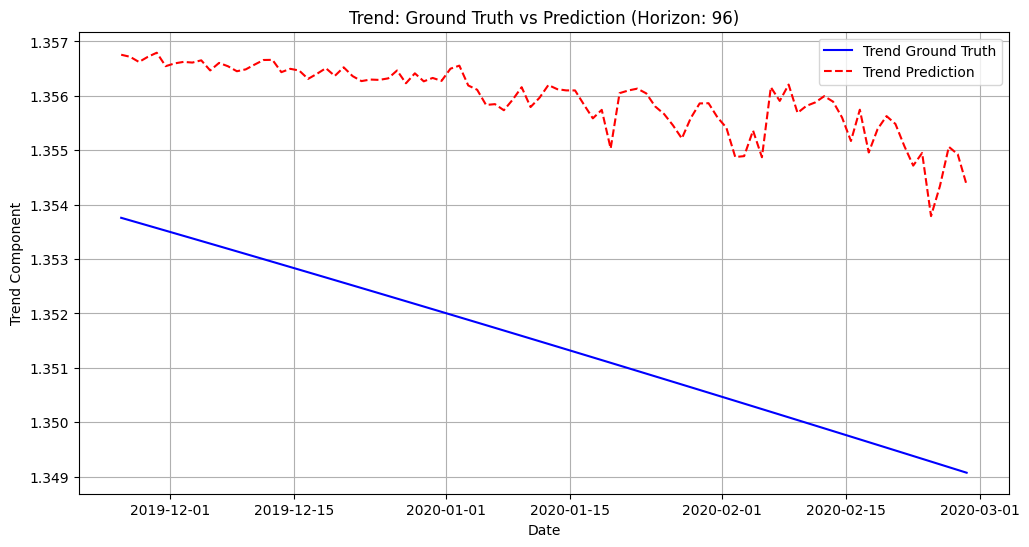

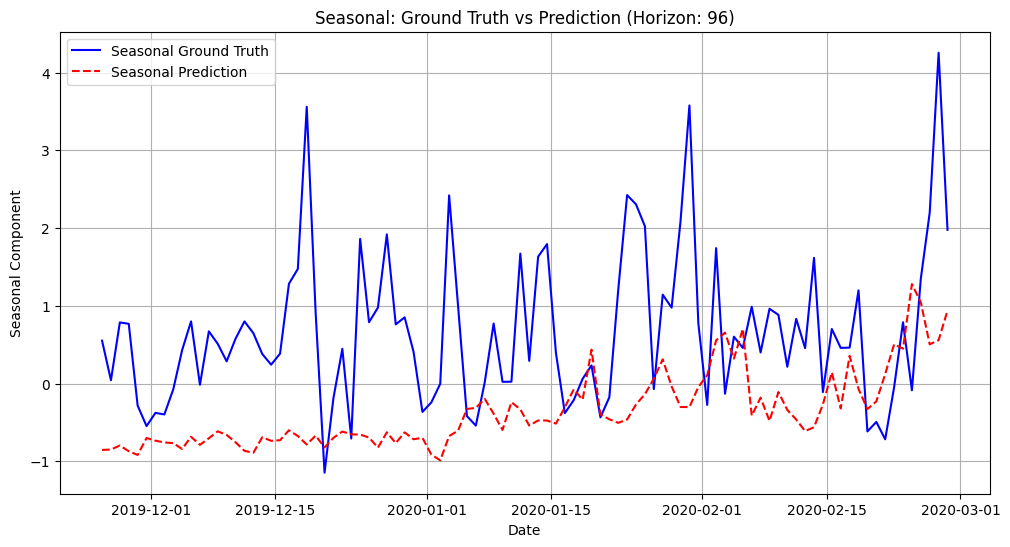

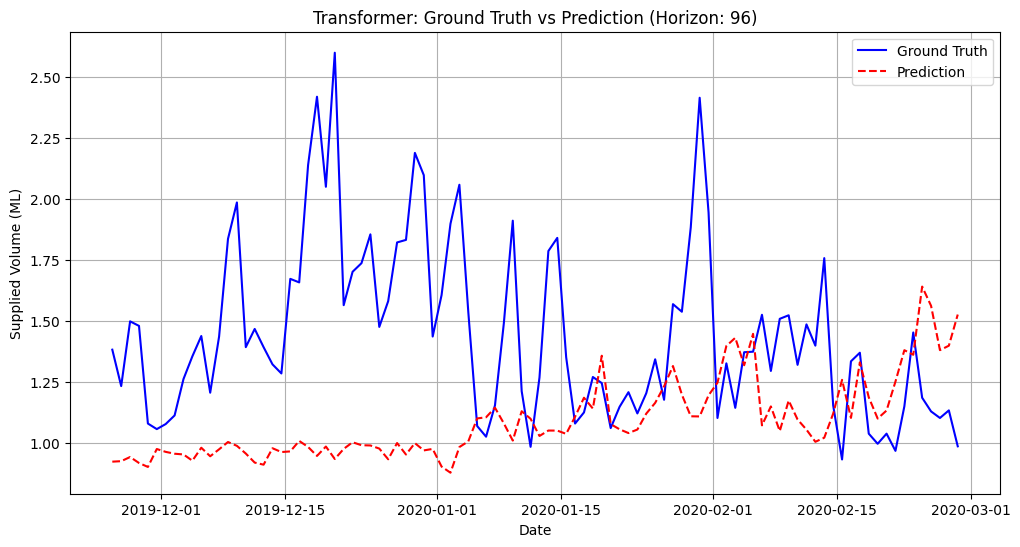


Processing horizon: 192

Results for Horizon: 192
Trend Training Time: 704.65 seconds
Trend Prediction Time: 0.0040 seconds
Seasonal Training Time: 700.07 seconds
Seasonal Prediction Time: 0.0041 seconds
Total Training Time: 1404.72 seconds
Total Prediction Time: 0.0081 seconds
Trend MSE: 0.006207
Trend MAE: 0.078750
Trend R²: -917.762854
Seasonal MSE: 2.495999
Seasonal MAE: 1.313550
Seasonal R²: -1.591117
Combined MSE: 0.318732
Combined MAE: 0.470058
Combined R²: -1.539855


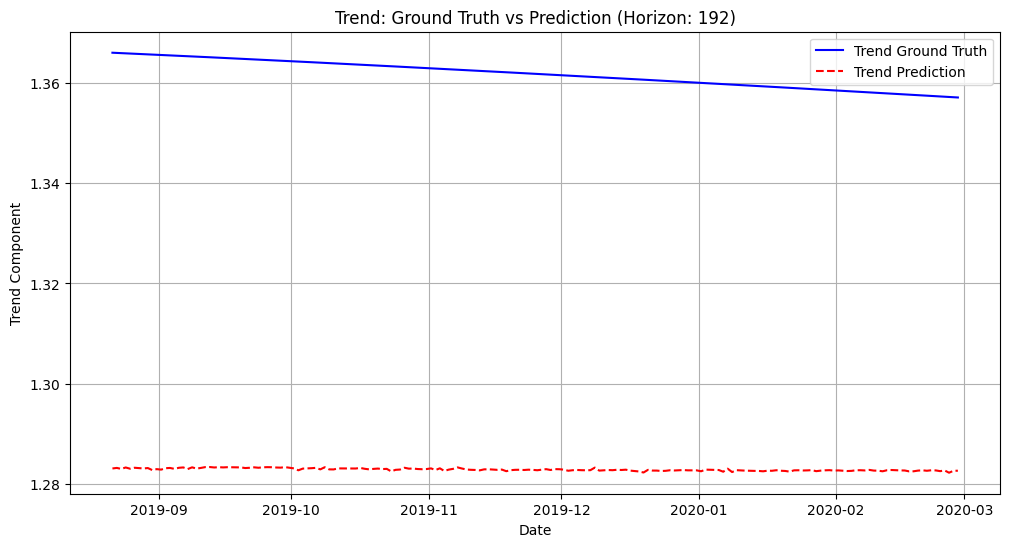

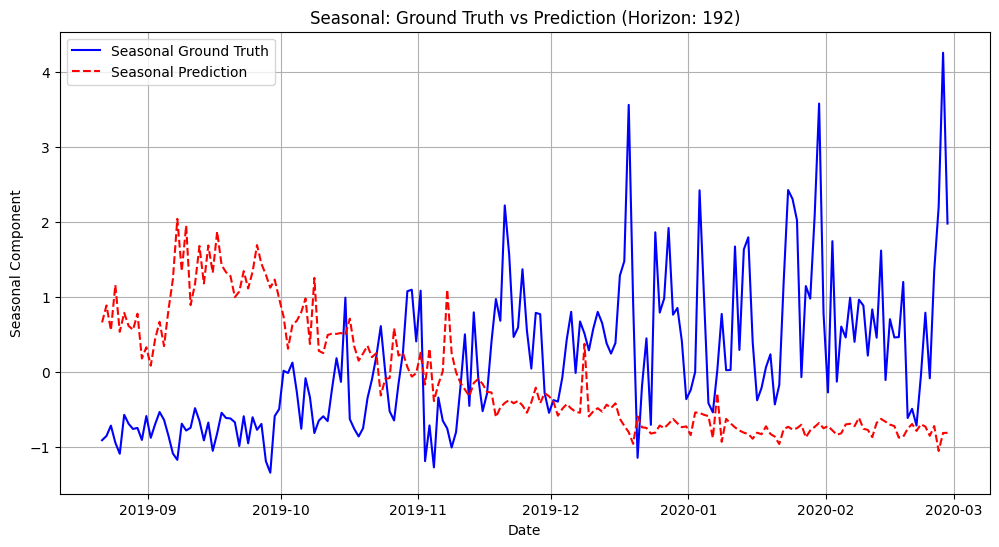

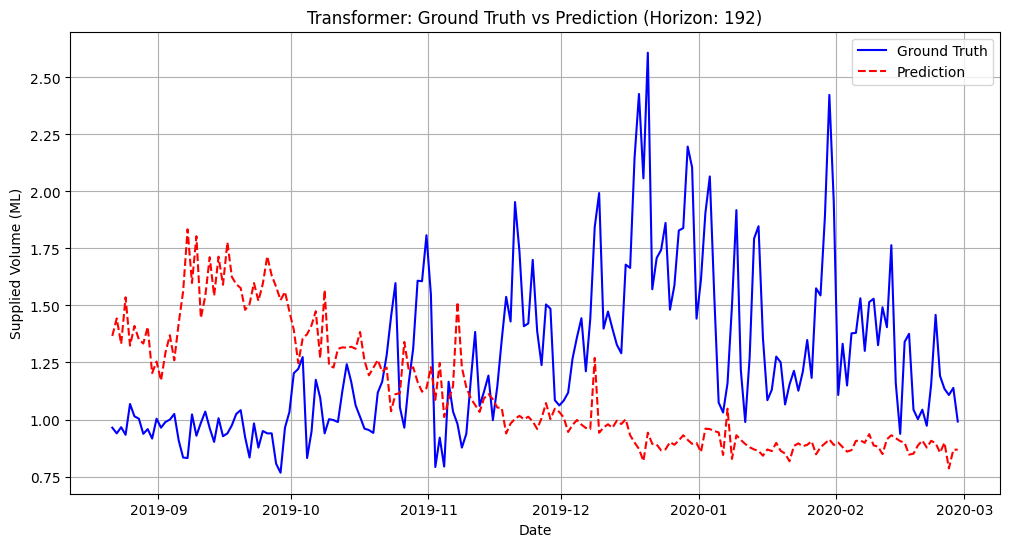


Processing horizon: 336

Results for Horizon: 336
Trend Training Time: 708.09 seconds
Trend Prediction Time: 0.0164 seconds
Seasonal Training Time: 695.19 seconds
Seasonal Prediction Time: 0.0138 seconds
Total Training Time: 1403.28 seconds
Total Prediction Time: 0.0302 seconds
Trend MSE: 0.012348
Trend MAE: 0.110911
Trend R²: -761.427103
Seasonal MSE: 0.555744
Seasonal MAE: 0.532136
Seasonal R²: 0.290905
Combined MSE: 0.078865
Combined MAE: 0.205280
Combined R²: 0.199795


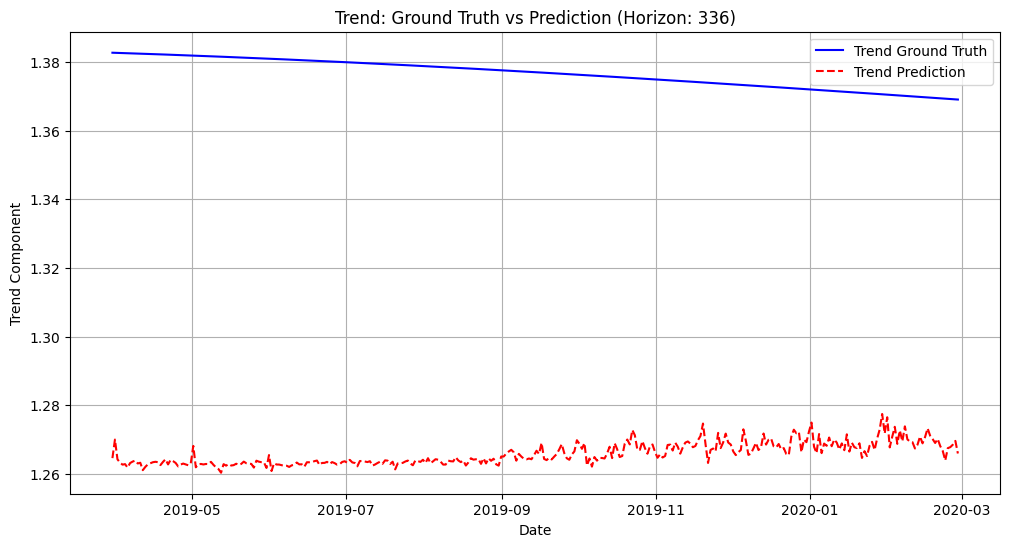

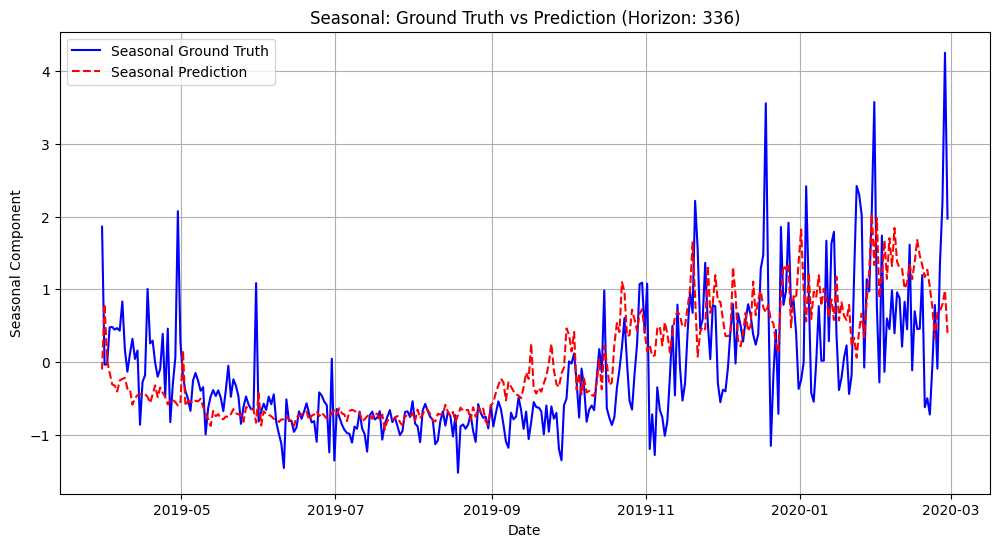

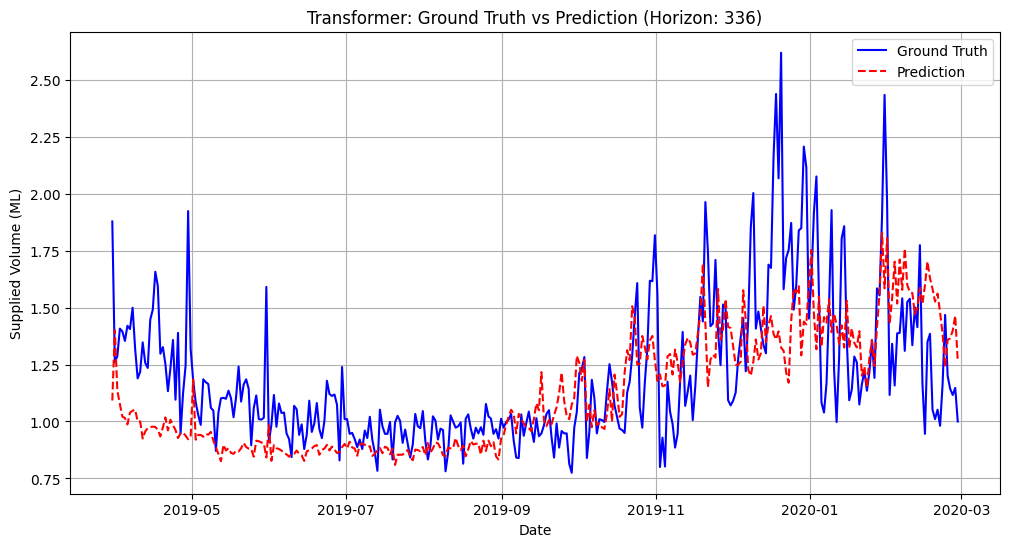


Processing horizon: 720

Results for Horizon: 720
Trend Training Time: 690.87 seconds
Trend Prediction Time: 0.0238 seconds
Seasonal Training Time: 662.08 seconds
Seasonal Prediction Time: 0.0118 seconds
Total Training Time: 1352.95 seconds
Total Prediction Time: 0.0356 seconds
Trend MSE: 0.070793
Trend MAE: 0.265880
Trend R²: -598.122185
Seasonal MSE: 0.433118
Seasonal MAE: 0.448856
Seasonal R²: 0.444801
Combined MSE: 0.142234
Combined MAE: 0.297791
Combined R²: -0.107470


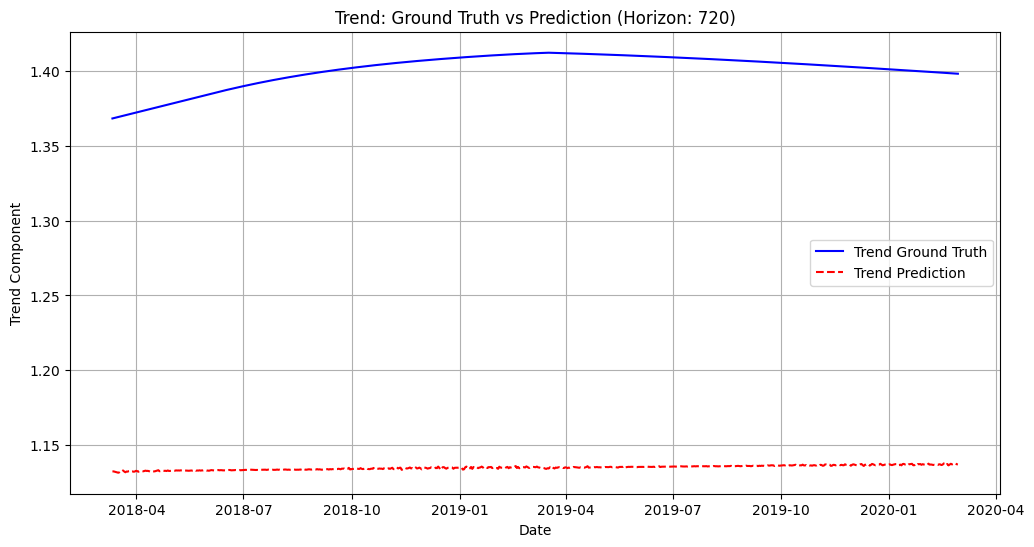

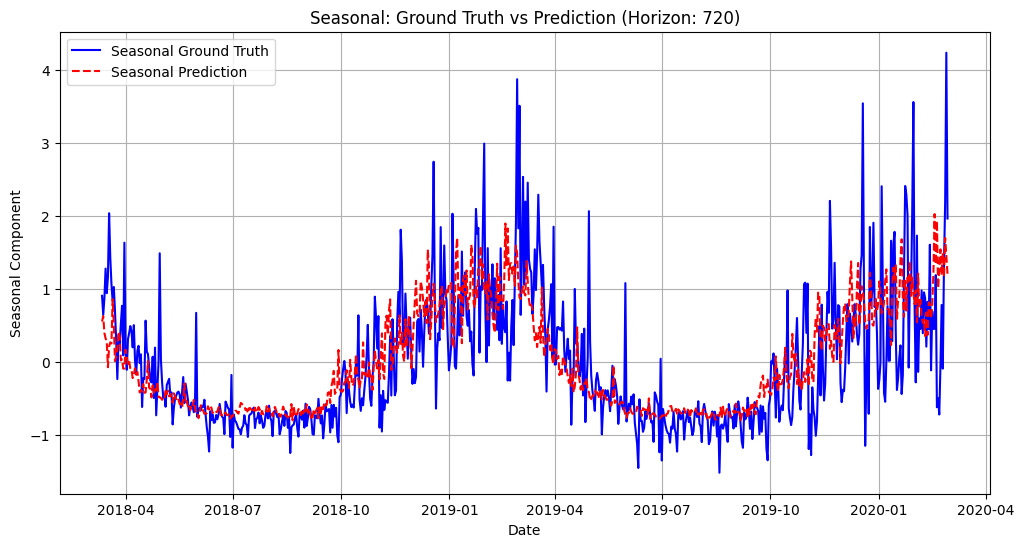

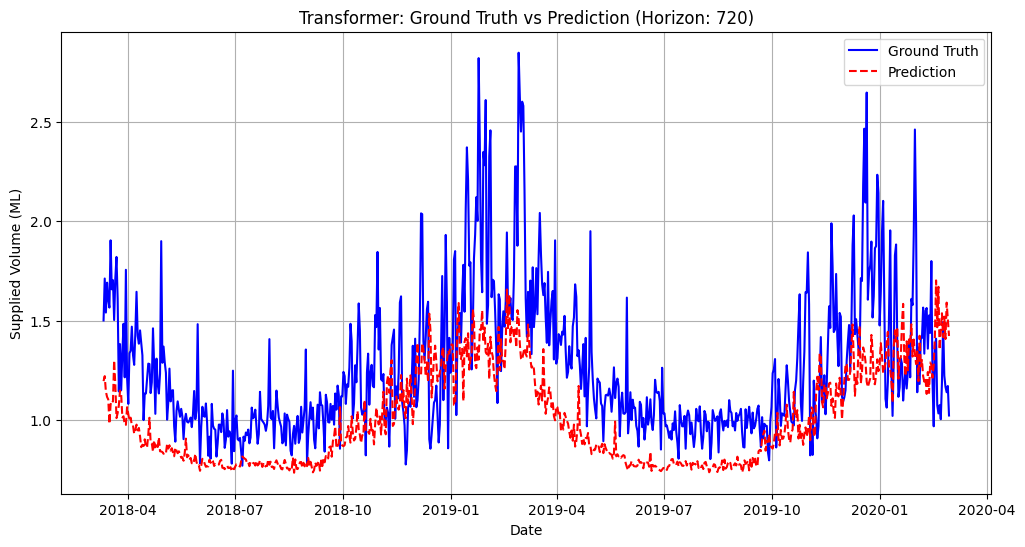

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time
import warnings
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore", category=FutureWarning, message=".*force_all_finite.*")
torch.manual_seed(42)
np.random.seed(42)

df = pd.read_csv('Water Supply - Daily Volume Drawn from storage dams operated by Melbourne Water/MWC_Daily_BulkWaterSupply_CompleteRecord_1674603204298011933.csv')
df['recorddate'] = pd.to_datetime(df['recorddate'], format='%m/%d/%Y %I:%M:%S %p')
df = df.sort_values('recorddate').reset_index(drop=True)
df = df.set_index('recorddate')
df = df[['supplied_ML']].copy()

def decompose_series(df, target_col, period=365):
    stl = STL(df[target_col], period=period, robust=True)
    result = stl.fit()
    df['trend'] = result.trend
    df['seasonal'] = result.seasonal
    df['resid'] = result.resid
    return df

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model, n_heads, num_layers=1, dropout=0.3):
        super().__init__()
        self.input_linear = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_linear = nn.Linear(d_model, 1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x = self.input_linear(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.dropout(x)
        x = self.output_linear(x[:, -1, :])
        return x

def prepare_data(df, trend_col, seasonal_col, horizon, seq_length=30):
    X = df[[trend_col, seasonal_col]].values
    y_trend = df[trend_col].values
    y_seasonal = df[seasonal_col].values
    y_original = df['supplied_ML'].values

    X_seq, y_trend_seq, y_seasonal_seq, y_original_seq = [], [], [], []
    for i in range(len(X) - seq_length - horizon + 1):
        X_seq.append(X[i:i + seq_length])
        y_trend_seq.append(y_trend[i + seq_length])
        y_seasonal_seq.append(y_seasonal[i + seq_length])
        y_original_seq.append(y_original[i + seq_length])
    
    X_seq = np.array(X_seq)
    y_trend_seq = np.array(y_trend_seq)
    y_seasonal_seq = np.array(y_seasonal_seq)
    y_original_seq = np.array(y_original_seq)
    
    train_size = len(X_seq) - horizon
    X_train = X_seq[:train_size]
    y_trend_train = y_trend_seq[:train_size]
    y_seasonal_train = y_seasonal_seq[:train_size]
    y_original_train = y_original_seq[:train_size]

    X_test = X_seq[-horizon:]
    y_trend_test = y_trend[-horizon:]
    y_seasonal_test = y_seasonal[-horizon:]
    y_original_test = y_original[-horizon:]

    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_test = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    scaler_y_trend = StandardScaler()
    y_trend_train_scaled = scaler_y_trend.fit_transform(y_trend_train.reshape(-1, 1)).flatten()

    scaler_y_seasonal = StandardScaler()
    y_seasonal_train_scaled = scaler_y_seasonal.fit_transform(y_seasonal_train.reshape(-1, 1)).flatten()

    scaler_y_original = StandardScaler()
    y_original_train_scaled = scaler_y_original.fit_transform(y_original_train.reshape(-1, 1)).flatten()

    return (X_train, y_trend_train_scaled, y_seasonal_train_scaled, y_original_train_scaled,
            X_test, y_trend_test, y_seasonal_test, y_original_test,
            scaler_y_trend, scaler_y_seasonal, scaler_y_original, scaler_X)

def train_and_evaluate(df, target_col, trend_col, seasonal_col, horizon, seq_length=30):
    (X_train, y_trend_train_scaled, y_seasonal_train_scaled, y_original_train_scaled,
     X_test, y_trend_test_raw, y_seasonal_test_raw, y_original_test_raw,
     scaler_y_trend, scaler_y_seasonal, scaler_y_original, scaler_X) = prepare_data(df, trend_col, seasonal_col, horizon, seq_length)

    X_train_tensor = torch.FloatTensor(X_train)
    y_trend_train_tensor = torch.FloatTensor(y_trend_train_scaled).reshape(-1, 1)
    y_seasonal_train_tensor = torch.FloatTensor(y_seasonal_train_scaled).reshape(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test)

    trend_model = TransformerModel(input_dim=2, d_model=16, n_heads=4, num_layers=1, dropout=0.3)
    seasonal_model = TransformerModel(input_dim=2, d_model=16, n_heads=4, num_layers=1, dropout=0.3)

    trend_optimizer = optim.Adam(trend_model.parameters(), lr=0.001)
    seasonal_optimizer = optim.Adam(seasonal_model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    epochs = 50
    batch_size = 64

    start_time = time.time()
    trend_model.train()
    for epoch in range(epochs):
        for i in range(0, len(X_train), batch_size):
            batch_X = X_train_tensor[i:i + batch_size]
            batch_y = y_trend_train_tensor[i:i + batch_size]
            trend_optimizer.zero_grad()
            output = trend_model(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            trend_optimizer.step()
    trend_training_time = time.time() - start_time

    start_time = time.time()
    trend_model.eval()
    with torch.no_grad():
        y_trend_pred_scaled = trend_model(X_test_tensor).numpy().flatten()
    trend_prediction_time = time.time() - start_time

    start_time = time.time()
    seasonal_model.train()
    for epoch in range(epochs):
        for i in range(0, len(X_train), batch_size):
            batch_X = X_train_tensor[i:i + batch_size]
            batch_y = y_seasonal_train_tensor[i:i + batch_size]
            seasonal_optimizer.zero_grad()
            output = seasonal_model(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            seasonal_optimizer.step()
    seasonal_training_time = time.time() - start_time

    start_time = time.time()
    seasonal_model.eval()
    with torch.no_grad():
        y_seasonal_pred_scaled = seasonal_model(X_test_tensor).numpy().flatten()
    seasonal_prediction_time = time.time() - start_time

    y_trend_pred = scaler_y_trend.inverse_transform(y_trend_pred_scaled.reshape(-1, 1)).flatten()
    y_seasonal_pred = scaler_y_seasonal.inverse_transform(y_seasonal_pred_scaled.reshape(-1, 1)).flatten()
    y_combined_pred = y_trend_pred + y_seasonal_pred

    y_trend_test_scaled = scaler_y_trend.transform(y_trend_test_raw.reshape(-1, 1)).flatten()
    y_seasonal_test_scaled = scaler_y_seasonal.transform(y_seasonal_test_raw.reshape(-1, 1)).flatten()
    y_original_test_scaled = scaler_y_original.transform(y_original_test_raw.reshape(-1, 1)).flatten()

    y_trend_pred_eval = scaler_y_trend.transform(y_trend_pred.reshape(-1, 1)).flatten()
    y_seasonal_pred_eval = scaler_y_seasonal.transform(y_seasonal_pred.reshape(-1, 1)).flatten()
    y_combined_pred_eval = scaler_y_original.transform(y_combined_pred.reshape(-1, 1)).flatten()

    trend_mse = mean_squared_error(y_trend_test_scaled, y_trend_pred_eval)
    trend_mae = mean_absolute_error(y_trend_test_scaled, y_trend_pred_eval)
    trend_r2 = r2_score(y_trend_test_scaled, y_trend_pred_eval)

    seasonal_mse = mean_squared_error(y_seasonal_test_scaled, y_seasonal_pred_eval)
    seasonal_mae = mean_absolute_error(y_seasonal_test_scaled, y_seasonal_pred_eval)
    seasonal_r2 = r2_score(y_seasonal_test_scaled, y_seasonal_pred_eval)

    combined_mse = mean_squared_error(y_original_test_scaled, y_combined_pred_eval)
    combined_mae = mean_absolute_error(y_original_test_scaled, y_combined_pred_eval)
    combined_r2 = r2_score(y_original_test_scaled, y_combined_pred_eval)

    print(f"\nResults for Horizon: {horizon}")
    print(f"Trend Training Time: {trend_training_time:.2f} seconds")
    print(f"Trend Prediction Time: {trend_prediction_time:.4f} seconds")
    print(f"Seasonal Training Time: {seasonal_training_time:.2f} seconds")
    print(f"Seasonal Prediction Time: {seasonal_prediction_time:.4f} seconds")
    print(f"Total Training Time: {trend_training_time + seasonal_training_time:.2f} seconds")
    print(f"Total Prediction Time: {trend_prediction_time + seasonal_prediction_time:.4f} seconds")
    print(f"Trend MSE: {trend_mse:.6f}")
    print(f"Trend MAE: {trend_mae:.6f}")
    print(f"Trend R²: {trend_r2:.6f}")
    print(f"Seasonal MSE: {seasonal_mse:.6f}")
    print(f"Seasonal MAE: {seasonal_mae:.6f}")
    print(f"Seasonal R²: {seasonal_r2:.6f}")
    print(f"Combined MSE: {combined_mse:.6f}")
    print(f"Combined MAE: {combined_mae:.6f}")
    print(f"Combined R²: {combined_r2:.6f}")

    test_index = df.index[-horizon:]

    plt.figure(figsize=(12, 6))
    plt.plot(test_index, y_trend_test_scaled, label='Trend Ground Truth', color='blue')
    plt.plot(test_index, y_trend_pred_eval, label='Trend Prediction', color='red', linestyle='--')
    plt.title(f'Trend: Ground Truth vs Prediction (Horizon: {horizon})')
    plt.xlabel('Date')
    plt.ylabel('Trend Component')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(test_index, y_seasonal_test_scaled, label='Seasonal Ground Truth', color='blue')
    plt.plot(test_index, y_seasonal_pred_eval, label='Seasonal Prediction', color='red', linestyle='--')
    plt.title(f'Seasonal: Ground Truth vs Prediction (Horizon: {horizon})')
    plt.xlabel('Date')
    plt.ylabel('Seasonal Component')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(test_index, y_original_test_scaled, label='Ground Truth', color='blue')
    plt.plot(test_index, y_combined_pred_eval, label='Prediction', color='red', linestyle='--')
    plt.title(f'Transformer: Ground Truth vs Prediction (Horizon: {horizon})')
    plt.xlabel('Date')
    plt.ylabel('Supplied Volume (ML)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        'trend_mse': trend_mse, 'trend_mae': trend_mae, 'trend_r2': trend_r2,
        'seasonal_mse': seasonal_mse, 'seasonal_mae': seasonal_mae, 'seasonal_r2': seasonal_r2,
        'combined_mse': combined_mse, 'combined_mae': combined_mae, 'combined_r2': combined_r2,
        'trend_training_time': trend_training_time, 'trend_prediction_time': trend_prediction_time,
        'seasonal_training_time': seasonal_training_time, 'seasonal_prediction_time': seasonal_prediction_time,
        'total_training_time': trend_training_time + seasonal_training_time,
        'total_prediction_time': trend_prediction_time + seasonal_prediction_time,
        'y_trend_test': y_trend_test_scaled, 'y_trend_pred': y_trend_pred_eval,
        'y_seasonal_test': y_seasonal_test_scaled, 'y_seasonal_pred': y_seasonal_pred_eval,
        'y_combined_test': y_original_test_scaled, 'y_combined_pred': y_combined_pred_eval,
        'test_index': test_index
    }

horizons = [96, 192, 336, 720]
df = decompose_series(df, 'supplied_ML', period=365)

for horizon in horizons:
    print(f"\nProcessing horizon: {horizon}")
    results = train_and_evaluate(df, 'supplied_ML', 'trend', 'seasonal', horizon)

# BLSTransformer


Processing horizon: 96

Results for Horizon: 96
Trend Training Time: 1.57 seconds
Trend Prediction Time: 0.0073 seconds
Seasonal Training Time: 0.68 seconds
Seasonal Prediction Time: 0.0048 seconds
Total Training Time: 2.25 seconds
Total Prediction Time: 0.0122 seconds
Trend MSE: 0.000000
Trend MAE: 0.000040
Trend R²: 0.998945
Seasonal MSE: 0.000000
Seasonal MAE: 0.000067
Seasonal R²: 1.000000
Combined MSE: 0.161162
Combined MAE: 0.211342
Combined R²: -0.256994


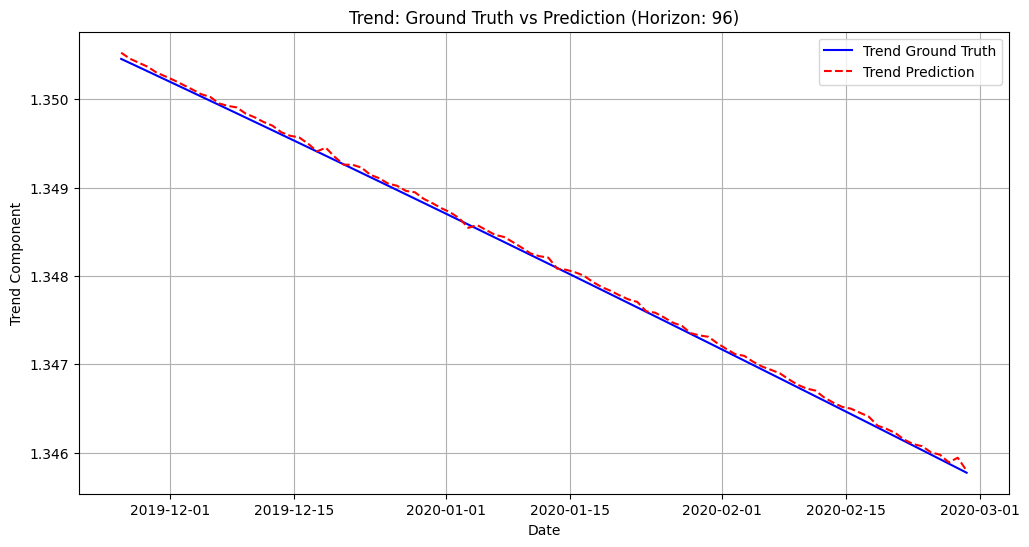

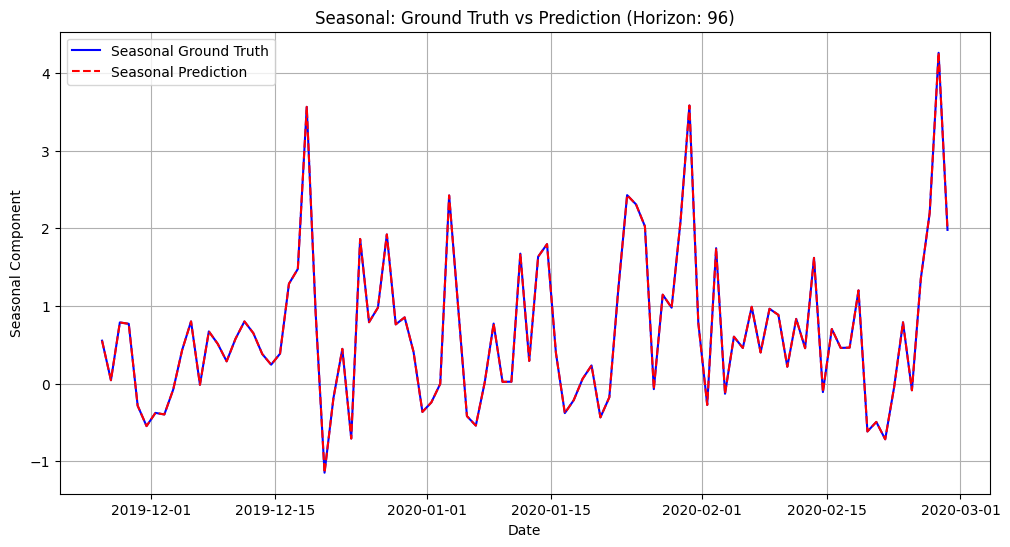

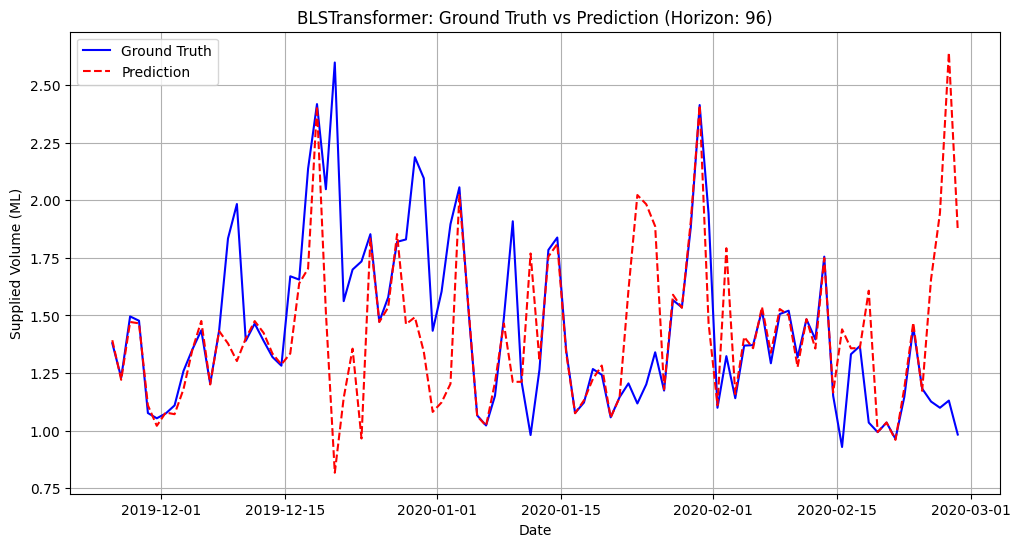


Processing horizon: 192

Results for Horizon: 192
Trend Training Time: 1.68 seconds
Trend Prediction Time: 0.0082 seconds
Seasonal Training Time: 0.70 seconds
Seasonal Prediction Time: 0.0056 seconds
Total Training Time: 2.39 seconds
Total Prediction Time: 0.0137 seconds
Trend MSE: 0.000000
Trend MAE: 0.000034
Trend R²: 0.999775
Seasonal MSE: 0.000000
Seasonal MAE: 0.000043
Seasonal R²: 1.000000
Combined MSE: 0.085419
Combined MAE: 0.127067
Combined R²: 0.317472


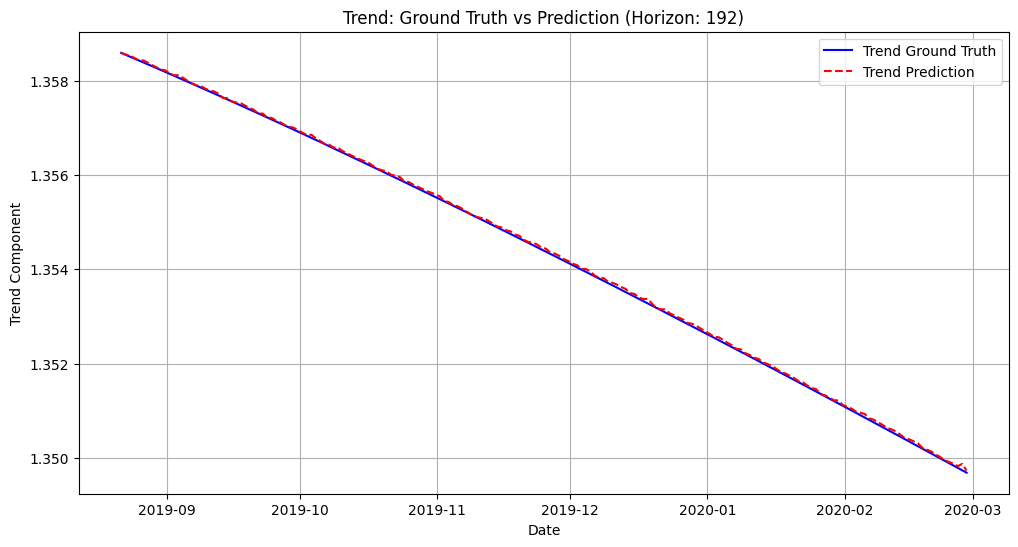

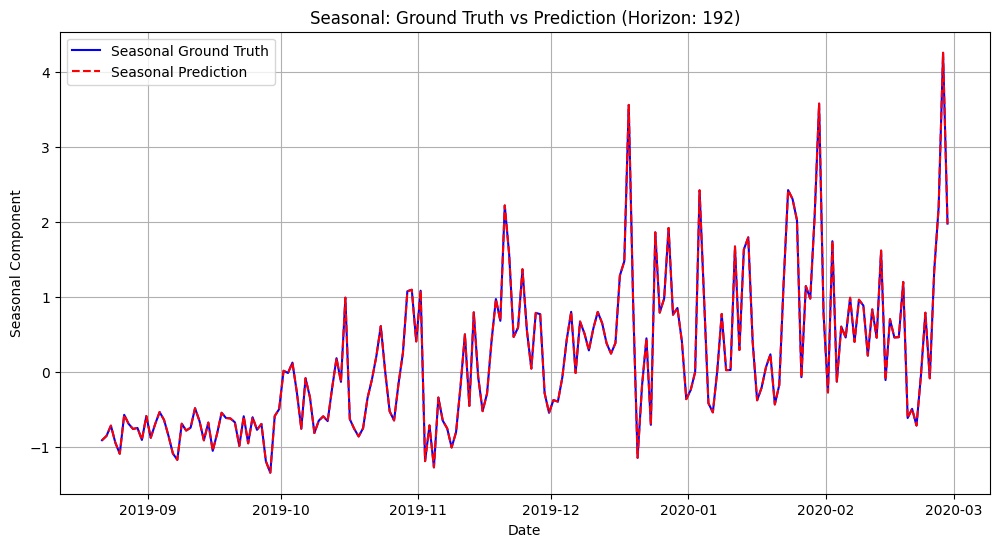

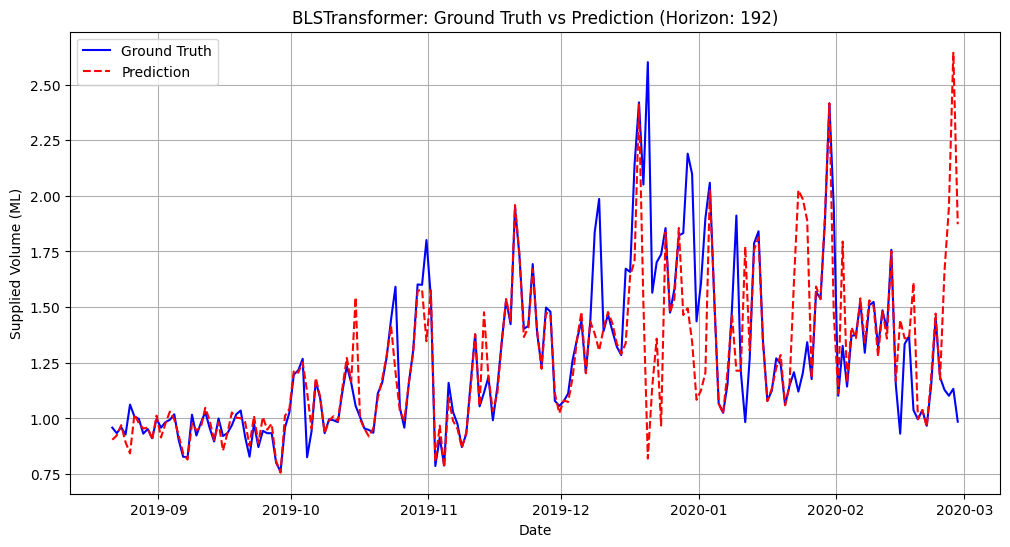


Processing horizon: 336

Results for Horizon: 336
Trend Training Time: 1.51 seconds
Trend Prediction Time: 0.0101 seconds
Seasonal Training Time: 0.73 seconds
Seasonal Prediction Time: 0.0081 seconds
Total Training Time: 2.24 seconds
Total Prediction Time: 0.0181 seconds
Trend MSE: 0.000000
Trend MAE: 0.000035
Trend R²: 0.999900
Seasonal MSE: 0.000000
Seasonal MAE: 0.000037
Seasonal R²: 1.000000
Combined MSE: 0.052210
Combined MAE: 0.090801
Combined R²: 0.467520


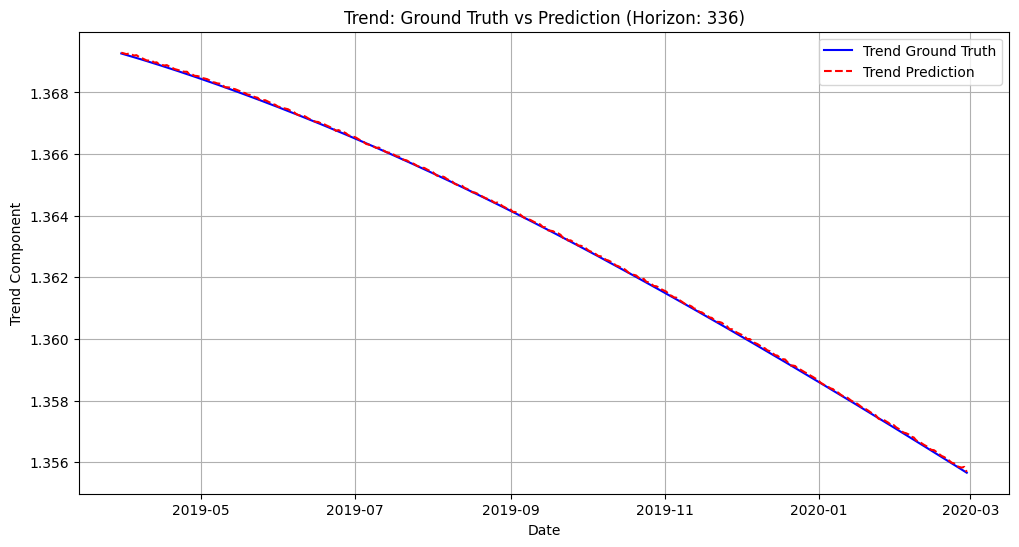

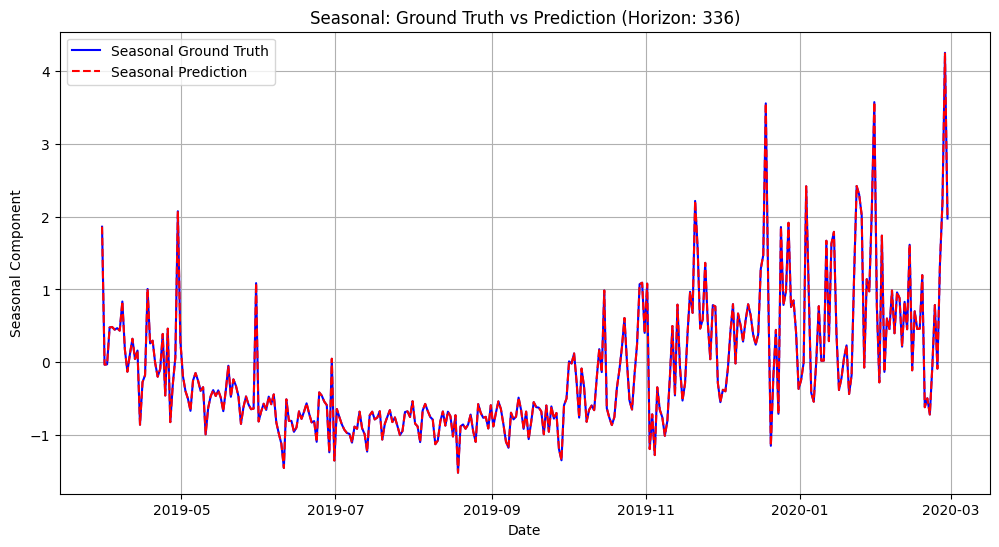

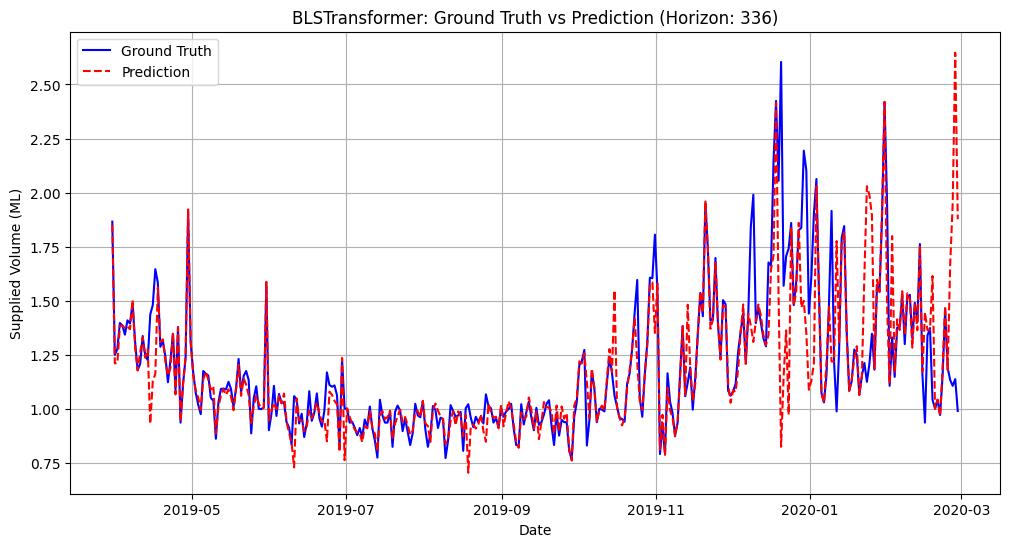


Processing horizon: 720

Results for Horizon: 720
Trend Training Time: 1.49 seconds
Trend Prediction Time: 0.0200 seconds
Seasonal Training Time: 0.71 seconds
Seasonal Prediction Time: 0.0101 seconds
Total Training Time: 2.20 seconds
Total Prediction Time: 0.0301 seconds
Trend MSE: 0.000000
Trend MAE: 0.000036
Trend R²: 0.999986
Seasonal MSE: 0.000000
Seasonal MAE: 0.000039
Seasonal R²: 1.000000
Combined MSE: 0.058065
Combined MAE: 0.120547
Combined R²: 0.545022


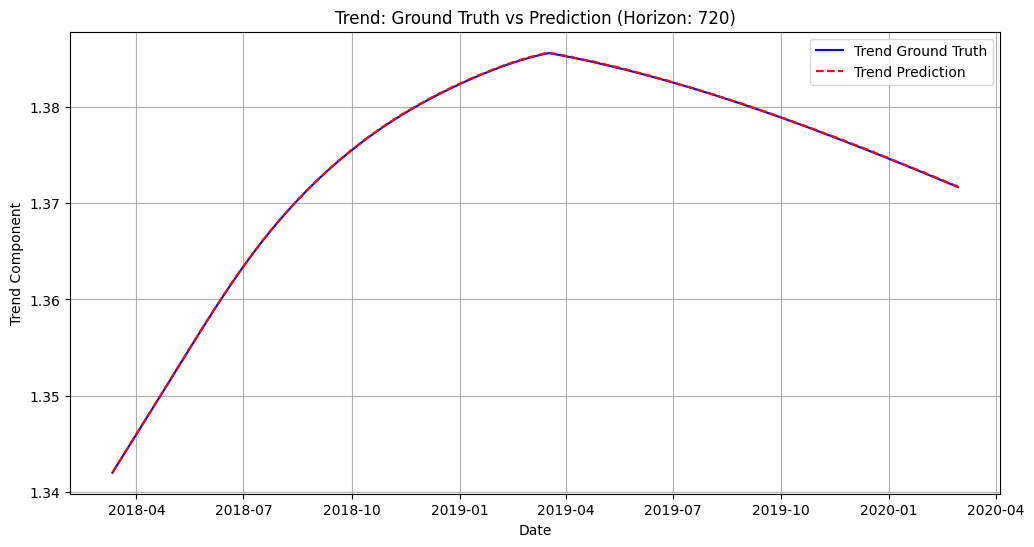

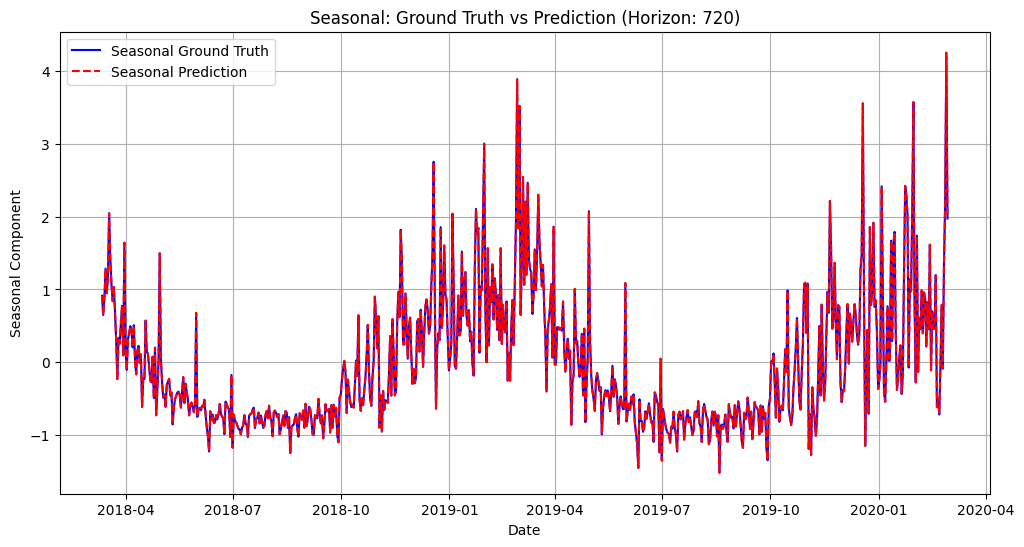

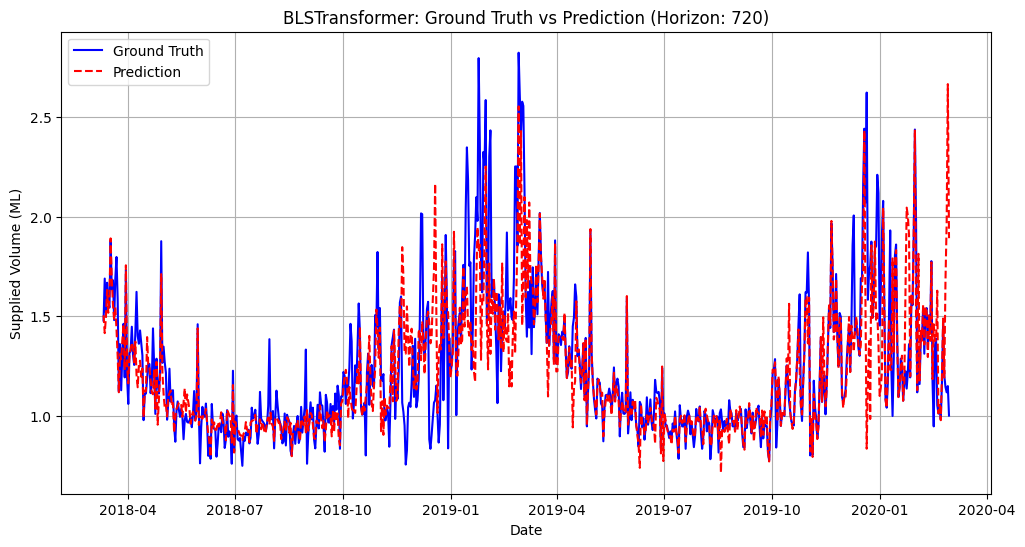

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time
import warnings
from statsmodels.tsa.seasonal import STL
warnings.filterwarnings("ignore", category=FutureWarning, message=".*force_all_finite.*")
torch.manual_seed(42)
np.random.seed(42)
df = pd.read_csv('Water Supply - Daily Volume Drawn from storage dams operated by Melbourne Water/MWC_Daily_BulkWaterSupply_CompleteRecord_1674603204298011933.csv')
df['recorddate'] = pd.to_datetime(df['recorddate'], format='%m/%d/%Y %I:%M:%S %p')
df = df.sort_values('recorddate').reset_index(drop=True)
df = df.set_index('recorddate')
df = df[['supplied_ML']].copy()
def decompose_series(df, target_col, period=365):
    stl = STL(df[target_col], period=period, robust=True)
    result = stl.fit()
    df['trend'] = result.trend
    df['seasonal'] = result.seasonal
    df['resid'] = result.resid
    return df
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]
class AttentionFeatureSelection(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.attention = nn.Linear(input_dim, input_dim)
        self.softmax = nn.Softmax(dim=-1)
    def forward(self, x):
        attn_weights = self.softmax(self.attention(x))
        return x * attn_weights
class BLSTransformer:
    def __init__(self, n_feature_nodes=8, n_enhancement_nodes=4, n_heads=2, d_model=8, random_state=42):
        self.n_feature_nodes = n_feature_nodes
        self.n_enhancement_nodes = n_enhancement_nodes
        self.n_heads = n_heads
        self.d_model = d_model
        self.random_state = random_state
        self.weights_feature = None
        self.weights_enhancement = None
        self.transformer = None
        self.attention_selection = None
        self.beta = None
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        self._feature_weight = 1.0
        self._transformer_weight = 1.0
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    def _create_transformer(self, input_dim):
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=self.n_heads,
            dim_feedforward=input_dim * 4,
            dropout=0.3,
            batch_first=True
        )
        transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        pos_enc = PositionalEncoding(input_dim)
        return nn.Sequential(pos_enc, transformer)
    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        X_norm = self.scaler_X.fit_transform(X)
        y_norm = self.scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
        self.weights_feature = np.random.randn(n_features, self.n_feature_nodes)
        H1 = self._sigmoid(X_norm @ self.weights_feature)
        self.attention_selection = AttentionFeatureSelection(self.n_feature_nodes)
        H1_torch = torch.FloatTensor(H1).unsqueeze(1)
        with torch.no_grad():
            H1_selected = self.attention_selection(H1_torch).squeeze(1).numpy()
        subset_size = min(self.d_model, self.n_feature_nodes)
        H1_subset = H1_selected[:, :subset_size]
        self.transformer = self._create_transformer(subset_size)
        with torch.no_grad():
            H1_trans = self.transformer(torch.FloatTensor(H1_subset).unsqueeze(1)).squeeze(1).numpy()
        if H1_trans.shape[1] < self.n_feature_nodes:
            pad_width = self.n_feature_nodes - H1_trans.shape[1]
            H1_trans = np.pad(H1_trans, ((0, 0), (0, pad_width)), mode='constant')
        elif H1_trans.shape[1] > self.n_feature_nodes:
            H1_trans = H1_trans[:, :self.n_feature_nodes]
        total_w = self._feature_weight + self._transformer_weight
        H_combined = (self._feature_weight * H1 + self._transformer_weight * H1_trans) / total_w
        self.weights_enhancement = np.random.randn(self.n_feature_nodes, self.n_enhancement_nodes)
        H2 = self._sigmoid(H_combined @ self.weights_enhancement)
        Z = np.hstack([H_combined, H2])
        lambda_reg = 1e-5
        ZTZ = Z.T @ Z + lambda_reg * np.eye(Z.shape[1])
        self.beta = np.linalg.solve(ZTZ, Z.T @ y_norm)
        return self
    def predict(self, X):
        X_norm = self.scaler_X.transform(X)
        H1 = self._sigmoid(X_norm @ self.weights_feature)
        H1_torch = torch.FloatTensor(H1).unsqueeze(1)
        with torch.no_grad():
            H1_selected = self.attention_selection(H1_torch).squeeze(1).numpy()
        subset_size = min(self.d_model, self.n_feature_nodes)
        H1_subset = H1_selected[:, :subset_size]
        with torch.no_grad():
            H1_trans = self.transformer(torch.FloatTensor(H1_subset).unsqueeze(1)).squeeze(1).numpy()
        if H1_trans.shape[1] < self.n_feature_nodes:
            pad_width = self.n_feature_nodes - H1_trans.shape[1]
            H1_trans = np.pad(H1_trans, ((0, 0), (0, pad_width)), mode='constant')
        elif H1_trans.shape[1] > self.n_feature_nodes:
            H1_trans = H1_trans[:, :self.n_feature_nodes]
        total_w = self._feature_weight + self._transformer_weight
        H_combined = (self._feature_weight * H1 + self._transformer_weight * H1_trans) / total_w
        H2 = self._sigmoid(H_combined @ self.weights_enhancement)
        Z = np.hstack([H_combined, H2])
        y_pred_norm = Z @ self.beta
        return self.scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
def prepare_data(df, trend_col, seasonal_col, horizon):
    X = df[[trend_col, seasonal_col]].values
    y_trend = df[trend_col].values
    y_seasonal = df[seasonal_col].values
    y_original = df['supplied_ML'].values
    train_size = len(X) - horizon
    X_train = X[:train_size]
    y_trend_train = y_trend[:train_size]
    y_seasonal_train = y_seasonal[:train_size]
    y_original_train = y_original[:train_size]
    X_test = X[-horizon:]
    y_trend_test = y_trend[-horizon:]
    y_seasonal_test = y_seasonal[-horizon:]
    y_original_test = y_original[-horizon:]
    return (X_train, y_trend_train, y_seasonal_train, y_original_train,
            X_test, y_trend_test, y_seasonal_test, y_original_test)
def train_and_evaluate(df, target_col, trend_col, seasonal_col, horizon):
    (X_train, y_trend_train, y_seasonal_train, y_original_train,
     X_test, y_trend_test_raw, y_seasonal_test_raw, y_original_test_raw) = prepare_data(df, trend_col, seasonal_col, horizon)
    trend_model = BLSTransformer(n_feature_nodes=400, n_enhancement_nodes=200, n_heads=4, d_model=8, random_state=42)
    start_time = time.time()
    trend_model.fit(X_train, y_trend_train)
    trend_training_time = time.time() - start_time
    start_time = time.time()
    y_trend_pred = trend_model.predict(X_test)
    trend_prediction_time = time.time() - start_time
    seasonal_model = BLSTransformer(n_feature_nodes=200, n_enhancement_nodes=100, n_heads=2, d_model=4, random_state=42)
    start_time = time.time()
    seasonal_model.fit(X_train, y_seasonal_train)
    seasonal_training_time = time.time() - start_time
    start_time = time.time()
    y_seasonal_pred = seasonal_model.predict(X_test)
    seasonal_prediction_time = time.time() - start_time
    y_combined_pred = y_trend_pred + y_seasonal_pred
    scaler_trend = StandardScaler().fit(y_trend_train.reshape(-1, 1))
    scaler_seasonal = StandardScaler().fit(y_seasonal_train.reshape(-1, 1))
    scaler_combined = StandardScaler().fit(y_original_train.reshape(-1, 1))
    y_trend_test_scaled = scaler_trend.transform(y_trend_test_raw.reshape(-1, 1)).flatten()
    y_trend_pred_scaled = scaler_trend.transform(y_trend_pred.reshape(-1, 1)).flatten()
    y_seasonal_test_scaled = scaler_seasonal.transform(y_seasonal_test_raw.reshape(-1, 1)).flatten()
    y_seasonal_pred_scaled = scaler_seasonal.transform(y_seasonal_pred.reshape(-1, 1)).flatten()
    y_combined_test_scaled = scaler_combined.transform(y_original_test_raw.reshape(-1, 1)).flatten()
    y_combined_pred_scaled = scaler_combined.transform(y_combined_pred.reshape(-1, 1)).flatten()
    trend_mse = mean_squared_error(y_trend_test_scaled, y_trend_pred_scaled)
    trend_mae = mean_absolute_error(y_trend_test_scaled, y_trend_pred_scaled)
    trend_r2 = r2_score(y_trend_test_scaled, y_trend_pred_scaled)
    seasonal_mse = mean_squared_error(y_seasonal_test_scaled, y_seasonal_pred_scaled)
    seasonal_mae = mean_absolute_error(y_seasonal_test_scaled, y_seasonal_pred_scaled)
    seasonal_r2 = r2_score(y_seasonal_test_scaled, y_seasonal_pred_scaled)
    combined_mse = mean_squared_error(y_combined_test_scaled, y_combined_pred_scaled)
    combined_mae = mean_absolute_error(y_combined_test_scaled, y_combined_pred_scaled)
    combined_r2 = r2_score(y_combined_test_scaled, y_combined_pred_scaled)
    print(f"\nResults for Horizon: {horizon}")
    print(f"Trend Training Time: {trend_training_time:.2f} seconds")
    print(f"Trend Prediction Time: {trend_prediction_time:.4f} seconds")
    print(f"Seasonal Training Time: {seasonal_training_time:.2f} seconds")
    print(f"Seasonal Prediction Time: {seasonal_prediction_time:.4f} seconds")
    print(f"Total Training Time: {trend_training_time + seasonal_training_time:.2f} seconds")
    print(f"Total Prediction Time: {trend_prediction_time + seasonal_prediction_time:.4f} seconds")
    print(f"Trend MSE: {trend_mse:.6f}")
    print(f"Trend MAE: {trend_mae:.6f}")
    print(f"Trend R²: {trend_r2:.6f}")
    print(f"Seasonal MSE: {seasonal_mse:.6f}")
    print(f"Seasonal MAE: {seasonal_mae:.6f}")
    print(f"Seasonal R²: {seasonal_r2:.6f}")
    print(f"Combined MSE: {combined_mse:.6f}")
    print(f"Combined MAE: {combined_mae:.6f}")
    print(f"Combined R²: {combined_r2:.6f}")
    test_index = df.index[-horizon:]
    plt.figure(figsize=(12, 6))
    plt.plot(test_index, y_trend_test_scaled, label='Trend Ground Truth', color='blue')
    plt.plot(test_index, y_trend_pred_scaled, label='Trend Prediction', color='red', linestyle='--')
    plt.title(f'Trend: Ground Truth vs Prediction (Horizon: {horizon})')
    plt.xlabel('Date')
    plt.ylabel('Trend Component')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(12, 6))
    plt.plot(test_index, y_seasonal_test_scaled, label='Seasonal Ground Truth', color='blue')
    plt.plot(test_index, y_seasonal_pred_scaled, label='Seasonal Prediction', color='red', linestyle='--')
    plt.title(f'Seasonal: Ground Truth vs Prediction (Horizon: {horizon})')
    plt.xlabel('Date')
    plt.ylabel('Seasonal Component')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(12, 6))
    plt.plot(test_index, y_combined_test_scaled, label='Ground Truth', color='blue')
    plt.plot(test_index, y_combined_pred_scaled, label='Prediction', color='red', linestyle='--')
    plt.title(f'BLSTransformer: Ground Truth vs Prediction (Horizon: {horizon})')
    plt.xlabel('Date')
    plt.ylabel('Supplied Volume (ML)')
    plt.legend()
    plt.grid(True)
    plt.show()
    return {
        'trend_mse': trend_mse, 'trend_mae': trend_mae, 'trend_r2': trend_r2,
        'seasonal_mse': seasonal_mse, 'seasonal_mae': seasonal_mae, 'seasonal_r2': seasonal_r2,
        'combined_mse': combined_mse, 'combined_mae': combined_mae, 'combined_r2': combined_r2,
        'trend_training_time': trend_training_time, 'trend_prediction_time': trend_prediction_time,
        'seasonal_training_time': seasonal_training_time, 'seasonal_prediction_time': seasonal_prediction_time,
        'total_training_time': trend_training_time + seasonal_training_time,
        'total_prediction_time': trend_prediction_time + seasonal_prediction_time,
        'y_trend_test': y_trend_test_scaled, 'y_trend_pred': y_trend_pred_scaled,
        'y_seasonal_test': y_seasonal_test_scaled, 'y_seasonal_pred': y_seasonal_pred_scaled,
        'y_combined_test': y_combined_test_scaled, 'y_combined_pred': y_combined_pred_scaled,
        'test_index': test_index
    }
horizons = [96, 192, 336, 720]
df = decompose_series(df, 'supplied_ML', period=365)
for horizon in horizons:
    print(f"\nProcessing horizon: {horizon}")
    results = train_and_evaluate(df, 'supplied_ML', 'trend', 'seasonal', horizon)